In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report, roc_curve)

sns.set_style("whitegrid")
np.random.seed(42)


## Load data

In [4]:
df = pd.read_csv("customer_churn.csv")
df.head()


,CustomerID,SeniorCitizen,Partner,Dependents,Tenure,Contract,InternetService,OnlineSecurity,TechSupport,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,0,No,Yes,51,One year,DSL,Yes,No,Yes,Mailed check,41.73,2154.82,No
1,CUST00002,0,Yes,Yes,14,Month-to-month,DSL,No,No,Yes,Mailed check,40.52,535.46,No
2,CUST00003,0,No,No,71,Month-to-month,DSL,Yes,Yes,Yes,Electronic check,35.72,2451.99,No
3,CUST00004,1,No,No,60,Month-to-month,DSL,No,No,Yes,Credit card,84.88,5113.11,No
4,CUST00005,0,Yes,No,20,Two year,Fiber optic,Yes,Yes,No,Electronic check,104.50,2051.85,No


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        2000 non-null   object 
 1   SeniorCitizen     2000 non-null   int64  
 2   Partner           2000 non-null   object 
 3   Dependents        2000 non-null   object 
 4   Tenure            2000 non-null   int64  
 5   Contract          2000 non-null   object 
 6   InternetService   2000 non-null   object 
 7   OnlineSecurity    2000 non-null   object 
 8   TechSupport       2000 non-null   object 
 9   PaperlessBilling  2000 non-null   object 
 10  PaymentMethod     2000 non-null   object 
 11  MonthlyCharges    2000 non-null   float64
 12  TotalCharges      1975 non-null   float64
 13  Churn             2000 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 218.9+ KB


In [6]:
df.isnull().sum()


,0
CustomerID,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
Contract,0
InternetService,0
OnlineSecurity,0
TechSupport,0
PaperlessBilling,0


In [7]:
df["Churn"].value_counts(normalize=True)


,proportion
Churn,
No,0.7505
Yes,0.2495


## EDA

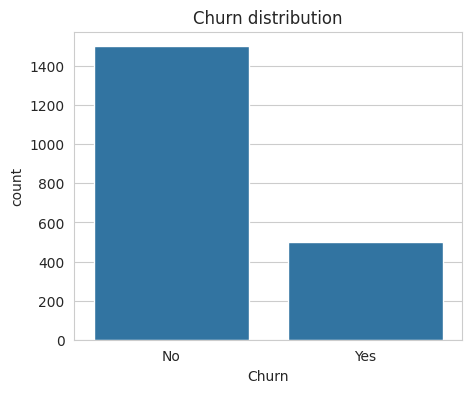

In [8]:
plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn distribution")
plt.show()


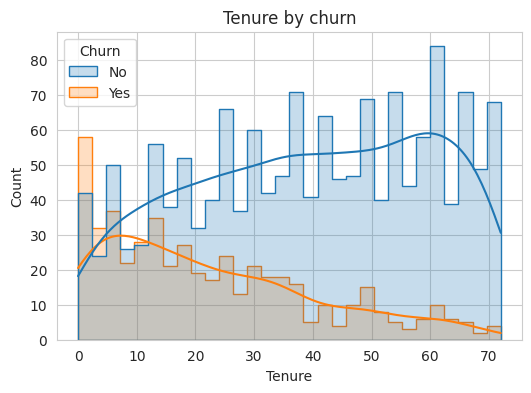

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="Tenure", hue="Churn", bins=30, kde=True, element="step")
plt.title("Tenure by churn")
plt.show()


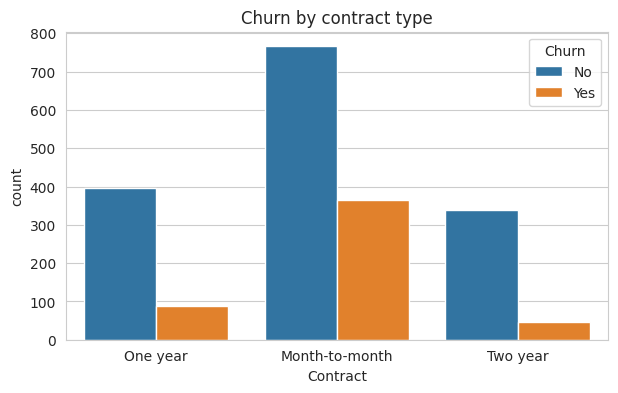

In [10]:
plt.figure(figsize=(7,4))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by contract type")
plt.show()


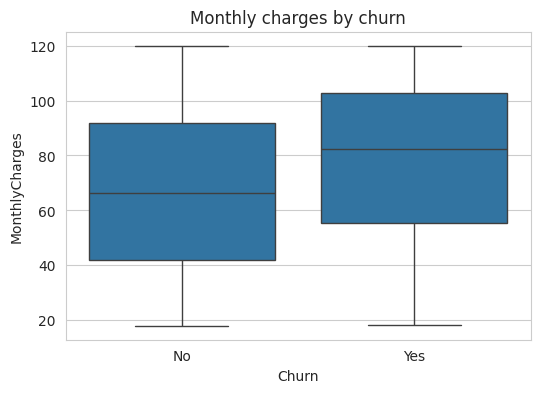

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly charges by churn")
plt.show()


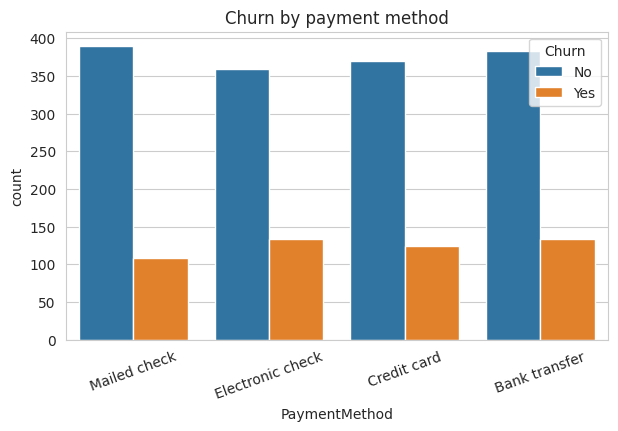

In [12]:
plt.figure(figsize=(7,4))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=20)
plt.title("Churn by payment method")
plt.show()


Customers on month-to-month contracts churn a lot more than those on annual contracts. Shorter tenure and higher monthly charges also line up with churn, and electronic check payers churn more than other payment methods. All fairly intuitive, but good to confirm before modeling.

## Preprocessing

In [13]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
df = df.drop(columns=["CustomerID"])

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})


In [14]:
num_features = ["Tenure", "MonthlyCharges", "TotalCharges"]
cat_features = ["SeniorCitizen", "Partner", "Dependents", "Contract", "InternetService",
                "OnlineSecurity", "TechSupport", "PaperlessBilling", "PaymentMethod"]

X = df[num_features + cat_features]
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [15]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(drop="first"), cat_features),
])


## Train models

In [16]:
logreg = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=500, class_weight="balanced")),
])
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)
logreg_proba = logreg.predict_proba(X_test)[:, 1]

rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)),
])
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

gb = Pipeline([
    ("prep", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42)),
])
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:, 1]


Used `class_weight="balanced"` for Logistic Regression and Random Forest so the minority churn class doesn't get ignored. Gradient Boosting doesn't take that param directly, so we lean on its probability threshold and the metrics below to judge it fairly.

In [17]:
models = {
    "Logistic Regression": (logreg, logreg_pred, logreg_proba),
    "Random Forest": (rf, rf_pred, rf_proba),
    "Gradient Boosting": (gb, gb_pred, gb_proba),
}

for name, (model, pred, proba) in models.items():
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)
    print(f"{name}: acc={acc:.3f}, precision={prec:.3f}, recall={rec:.3f}, f1={f1:.3f}, auc={auc:.3f}")


Logistic Regression: acc=0.720, precision=0.464, recall=0.780, f1=0.582, auc=0.814
Random Forest: acc=0.752, precision=0.511, recall=0.240, f1=0.327, auc=0.751
Gradient Boosting: acc=0.795, precision=0.655, recall=0.380, f1=0.481, auc=0.800


## Confusion matrices and ROC curves

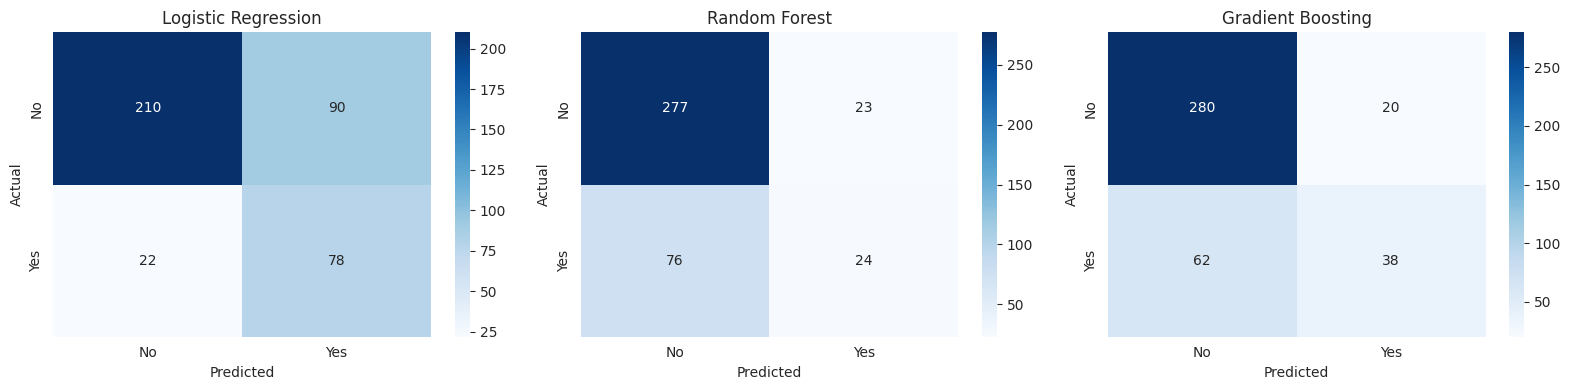

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, (model, pred, proba)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


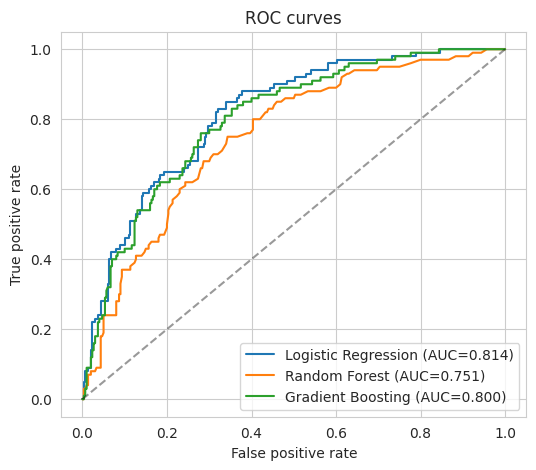

In [19]:
plt.figure(figsize=(6,5))
for name, (model, pred, proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1], [0,1], "k--", alpha=0.4)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves")
plt.legend()
plt.show()


In [20]:
for name, (model, pred, proba) in models.items():
    print(name)
    print(classification_report(y_test, pred, target_names=["No churn", "Churn"]))


Logistic Regression
              precision    recall  f1-score   support

    No churn       0.91      0.70      0.79       300
       Churn       0.46      0.78      0.58       100

    accuracy                           0.72       400
   macro avg       0.68      0.74      0.69       400
weighted avg       0.79      0.72      0.74       400

Random Forest
              precision    recall  f1-score   support

    No churn       0.78      0.92      0.85       300
       Churn       0.51      0.24      0.33       100

    accuracy                           0.75       400
   macro avg       0.65      0.58      0.59       400
weighted avg       0.72      0.75      0.72       400

Gradient Boosting
              precision    recall  f1-score   support

    No churn       0.82      0.93      0.87       300
       Churn       0.66      0.38      0.48       100

    accuracy                           0.80       400
   macro avg       0.74      0.66      0.68       400
weighted avg       0.7

Recall on the churn class matters more than raw accuracy here, missing an actual churner is more costly than a false alarm, since the whole point is catching people before they leave. That's exactly where Logistic Regression with balanced class weights pulls ahead, it catches far more actual churners than the tree-based models even though its precision is lower. Random Forest and Gradient Boosting post higher accuracy but miss most churners, which defeats the purpose here.

## Feature importance

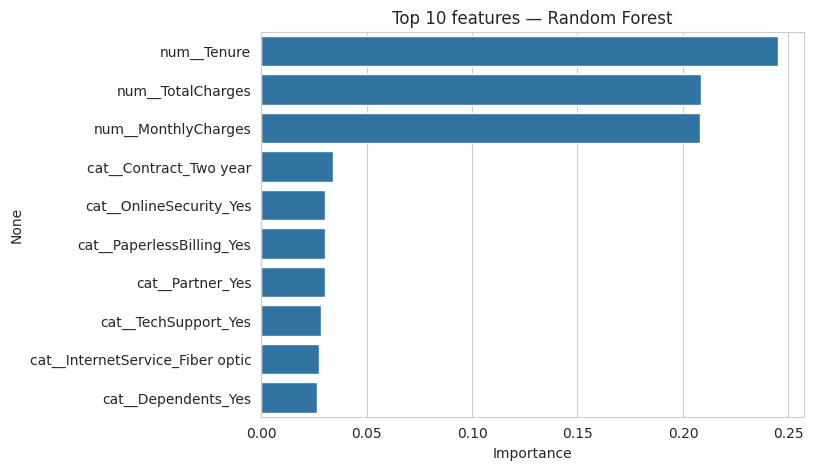

In [21]:
rf_model = rf.named_steps["model"]
feature_names = rf.named_steps["prep"].get_feature_names_out()

importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 10 features — Random Forest")
plt.xlabel("Importance")
plt.show()


Tenure, monthly charges, and contract type dominate. That matches what we saw in EDA and gives a clear story for the business summary: contract length and pricing are the biggest levers for reducing churn.

## Save the best model

In [22]:
best_name = max(models, key=lambda n: roc_auc_score(y_test, models[n][2]))
best_model = models[best_name][0]

print("Best model:", best_name)


Best model: Logistic Regression


In [23]:
joblib.dump(best_model, "churn_model.joblib")


['churn_model.joblib']

In [24]:
from google.colab import files
files.download("churn_model.joblib")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Inference example

In [25]:
def predict_churn(tenure, monthly_charges, total_charges, senior_citizen, partner, dependents,
                   contract, internet_service, online_security, tech_support,
                   paperless_billing, payment_method):
    model = joblib.load("churn_model.joblib")

    x = pd.DataFrame([{
        "Tenure": tenure,
        "MonthlyCharges": monthly_charges,
        "TotalCharges": total_charges,
        "SeniorCitizen": senior_citizen,
        "Partner": partner,
        "Dependents": dependents,
        "Contract": contract,
        "InternetService": internet_service,
        "OnlineSecurity": online_security,
        "TechSupport": tech_support,
        "PaperlessBilling": paperless_billing,
        "PaymentMethod": payment_method,
    }])
    proba = model.predict_proba(x)[0, 1]
    return "Yes" if proba >= 0.5 else "No", round(proba, 3)


predict_churn(3, 95.5, 300, 0, "No", "No", "Month-to-month", "Fiber optic", "No", "No", "Yes", "Electronic check")


('Yes', np.float64(0.939))